**Supervised Model**

In [7]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder

notebook_dir = Path().resolve()
project_root = notebook_dir
for _ in range(6):
    if (project_root / 'requirements.txt').exists(): break
    project_root = project_root.parent
sys.path.insert(0, str(project_root / 'src'))
from data_ai.config import DATA_PROCESSED_DIR, ARTIFACT_MODELS_DIR, ARTIFACT_REPORTS_DIR

df = pd.read_csv(DATA_PROCESSED_DIR / 'cleaned_car_data.csv')
print(f'Loaded {len(df)} rows, {df.shape[1]} columns')
df.head(3)

Loaded 735 rows, 21 columns


,id,car_id,event,timestamp,hit,speed,isMoving,hitStrength,orientation,speed_enc,...,orientation_enc,event_enc,hit_int,isMoving_int,damage_score,t_sec,roll_hit_rate,roll_moving_rate,roll_damage,window_10s
0,1,2,speed,2026-05-20 09:51:18.856883,False,stopped,False,none,NaN,0.0,...,NaN,1,0,0,0,0.000000,0.0,0.0,0.0,0
1,2,2,speed,2026-05-20 09:51:19.154162,False,stopped,False,none,NaN,0.0,...,NaN,1,0,0,0,0.297279,0.0,0.0,0.0,0
2,3,2,speed,2026-05-20 09:51:19.159086,False,stopped,False,none,NaN,0.0,...,NaN,1,0,0,0,0.302203,0.0,0.0,0.0,0


**Feature ( `orientation_enc` has NaNs
(sensor reported 'unknown') we fill with `-1` to represent 'no reading')**

In [8]:
FEATURE_COLS = ['speed_enc', 'isMoving_int', 'orientation_enc',
                'roll_moving_rate', 'roll_hit_rate', 'roll_damage']
TARGET_COL   = 'hit_int'

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# Fill NaN orientation  & speed with -1 ('sensor unknown')
X['orientation_enc'] = X['orientation_enc'].fillna(-1)
X['speed_enc'] = X['speed_enc'].fillna(-1)

print(f'Features shape: {X.shape}')
print(f'Class balance  — hit=0: {(y==0).sum()}  hit=1: {(y==1).sum()}')
print(f'Positive rate: {y.mean()*100:.1f}%')

Features shape: (735, 6)
Class balance  — hit=0: 707  hit=1: 28
Positive rate: 3.8%


**Training / split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train positives: {y_train.sum()}  |  Test positives: {y_test.sum()}')

Train: 588 rows  |  Test: 147 rows
Train positives: 22  |  Test positives: 6


**Randomforest is the current choosen one for now but also i need more data for this supervised model to be accurate idk**

In [10]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

# 5-fold CV on full dataset
cv_scores = cross_val_score(
    clf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),scoring='f1')
print(f'CV F1 scores: {cv_scores.round(3)}')
print(f'Mean F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

CV F1 scores: [1.    0.909 1.    1.    0.909]
Mean F1: 0.964 ± 0.045


**Evaluate the model**

In [11]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not hit', 'Hit']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}')


Classification Report:
              precision    recall  f1-score   support

     Not hit       1.00      1.00      1.00       141
         Hit       1.00      1.00      1.00         6

    accuracy                           1.00       147
   macro avg       1.00      1.00      1.00       147
weighted avg       1.00      1.00      1.00       147

ROC-AUC: 1.000


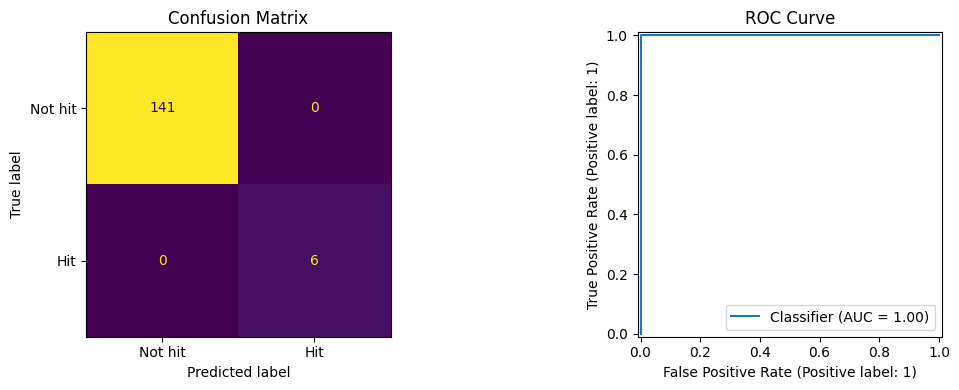

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Not hit', 'Hit']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.savefig(ARTIFACT_REPORTS_DIR / 'supervised_evaluation.png', dpi=120)
plt.show()

**feature importance**

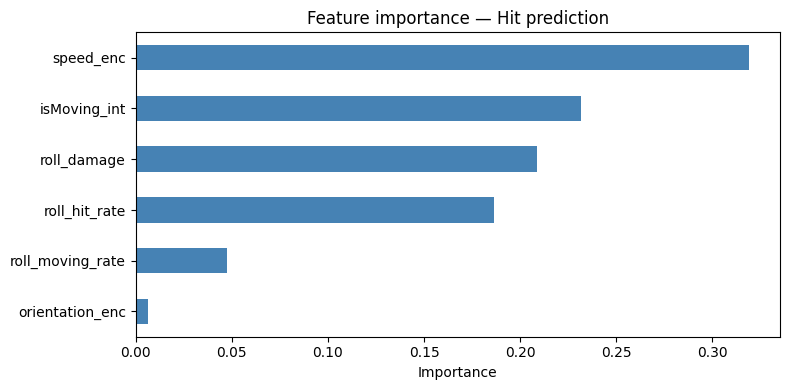

Top feature: speed_enc


In [13]:
importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature importance — Hit prediction')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(ARTIFACT_REPORTS_DIR / 'feature_importance.png', dpi=120)
plt.show()

print('Top feature:', importances.idxmax())

**winner analysis for 10 sec**

In [14]:
window_stats = (
    df.groupby(['car_id', 'window_10s'])
    .agg(
        total_damage   = ('damage_score', 'sum'),
        hit_count      = ('hit_int', 'sum'),
        avg_speed      = ('speed_enc', 'mean'),
        moving_rate    = ('isMoving_int', 'mean'),
        n_readings     = ('id', 'count')
    ).reset_index()
)

# Per window: rank cars by damage (lower = better)
window_stats['damage_rank'] = window_stats.groupby('window_10s')['total_damage'].rank(method='min')
window_stats['wins_window'] = (window_stats['damage_rank'] == 1).astype(int)

summary = window_stats.groupby('car_id').agg(
    windows_won   = ('wins_window', 'sum'),
    total_damage  = ('total_damage', 'sum'),
    total_hits    = ('hit_count', 'sum'),
)
print('Per-car session summary:')
print(summary)
print()
winner = summary['total_damage'].idxmin()
print(f'Overall winner (least damage): Car {winner}')

Per-car session summary:
        windows_won  total_damage  total_hits
car_id                                       
2                11            28          28

Overall winner (least damage): Car 2


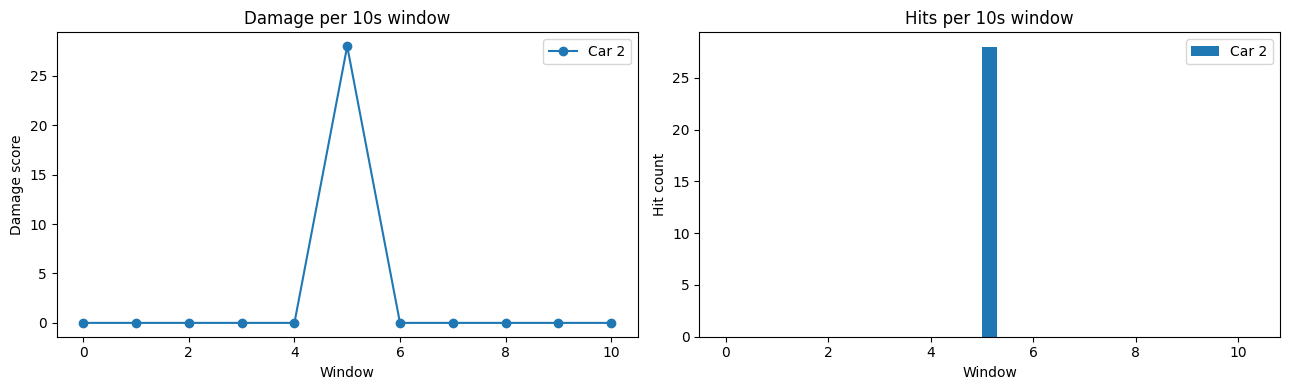

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for car_id, grp in window_stats.groupby('car_id'):
    axes[0].plot(grp['window_10s'], grp['total_damage'], marker='o', label=f'Car {car_id}')
    axes[1].bar(grp['window_10s'] + (car_id - 1.5) * 0.3, grp['hit_count'],
                width=0.3, label=f'Car {car_id}')

axes[0].set(title='Damage per 10s window', xlabel='Window', ylabel='Damage score')
axes[0].legend()
axes[1].set(title='Hits per 10s window', xlabel='Window', ylabel='Hit count')
axes[1].legend()
plt.tight_layout()
plt.savefig(ARTIFACT_REPORTS_DIR / 'winner_analysis.png', dpi=120)
plt.show()

**Save model**

In [16]:
MODEL_PATH = ARTIFACT_MODELS_DIR / 'hit_predictor_rf.pkl'
joblib.dump(clf, MODEL_PATH)
print(f'Model saved → {MODEL_PATH}')

Model saved → /Users/user/Documents/Ucll/3rd Yr/Integration Project/Data-AI-T1-/artifacts/models/hit_predictor_rf.pkl
